# Tahap 2 - Case Representation
Notebook ini mengeksekusi Tahap 2 dari pipeline Case-Based Reasoning (CBR). Fokus utama adalah mengonversi data teks putusan mentah menjadi representasi terstruktur (*Metadata* dan *Feature Engineering*) yang siap digunakan untuk NLP, TF-IDF, dan sistem *Retrieval*.

## 1. Import dan Instalasi Library
Pustaka yang digunakan mencakup `pandas` untuk manipulasi data tabular, `re` untuk *RegEx* (ekstraksi metadata), dan `sklearn` untuk *Feature Engineering*.

In [1]:
!pip install pandas numpy nltk Sastrawi tqdm scikit-learn matplotlib seaborn

import os
import re
import glob
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

print("Semua library berhasil diimpor!")

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: C:\Users\wongp\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Semua library berhasil diimpor!


## 2. Membaca File Cleaned Text & Raw Text
Kita akan memuat hasil *preprocessing* dari tahap sebelumnya (`/data/processed/*_clean.txt`). Kita juga membutuhkan teks *raw* (`/data/raw/*.txt`) untuk mengekstrak *metadata* yang format aslinya (seperti Nomor Perkara yang berisi garis miring dan huruf besar) mungkin telah hilang saat *cleaning*.

In [2]:
base_path = "../"
processed_dir = os.path.join(base_path, "data/processed")
raw_dir = os.path.join(base_path, "data/raw")

clean_files = glob.glob(os.path.join(processed_dir, "*_clean.txt"))
print(f"Ditemukan {len(clean_files)} file teks bersih.")

# Fungsi bantu untuk membaca file
def read_text(filepath):
    if not os.path.exists(filepath):
        return ""
    with open(filepath, "r", encoding="utf-8") as f:
        return f.read()

Ditemukan 45 file teks bersih.


## 3 & 4. Fungsi Ekstraksi Metadata & Konten Kunci (RegEx)
Ekstraksi didasarkan pada *pattern matching* (RegEx) standar dokumen Pengadilan Agama (Cerai Gugat).

In [3]:
def extract_metadata(raw_text):
    """
    Mengekstrak Nomor Perkara, Tanggal, Pasal, Pihak, Amar Putusan, 
    dan Ringkasan Fakta/Alasan dari teks asli dokumen putusan.
    """
    meta = {
        "no_perkara": "tidak ditemukan",
        "tanggal": "tidak ditemukan",
        "jenis_perkara": "Cerai Gugat", # Hardcode untuk domain ini
        "pihak": "Penggugat vs Tergugat",
        "pasal": "tidak ditemukan",
        "amar_putusan": "tidak ditemukan",
        "alasan_perceraian": "tidak ditemukan",
        "ringkasan_fakta": "tidak ditemukan"
    }
    
    # 1. Nomor Perkara (Contoh: Nomor 123/Pdt.G/2024/PA.Jkt)
    match_no = re.search(r"Nomor\s*[:]?\s*(\d+/Pdt\.G/\d{4}/PA\.[A-Za-z]+)", raw_text, re.IGNORECASE)
    if match_no:
        meta["no_perkara"] = match_no.group(1)
        
    # 2. Tanggal Putusan (Mencari pola 'tanggal 12 Januari 2024')
    match_tgl = re.search(r"tanggal\s+(\d{1,2}\s+(?:Januari|Februari|Maret|April|Mei|Juni|Juli|Agustus|September|Oktober|November|Desember)\s+\d{4})", raw_text, re.IGNORECASE)
    if match_tgl:
        meta["tanggal"] = match_tgl.group(1)
        
    # 3. Pihak (Heuristik: Menangkap nama sebelum kata 'sebagai Penggugat' dan 'Tergugat')
    penggugat = re.search(r"([A-Za-z\s]+)\s+(?:bin|binti|umur).*?sebagai\s*Penggugat", raw_text, re.IGNORECASE)
    tergugat = re.search(r"([A-Za-z\s]+)\s+(?:bin|binti|umur).*?sebagai\s*Tergugat", raw_text, re.IGNORECASE)
    if penggugat and tergugat:
        meta["pihak"] = f"{penggugat.group(1).strip()} vs {tergugat.group(1).strip()}"

    # 4. Pasal (Mencari rujukan pasal terdekat sebelum MENGADILI)
    pasal_matches = re.findall(r"(Pasal\s+\d+\s+[^\n\.,]*)", raw_text, re.IGNORECASE)
    if pasal_matches:
        # Ambil maksimal 3 rujukan pasal pertama untuk konteks
        meta["pasal"] = ", ".join(list(set(pasal_matches))[:3])
        
    # 5. Amar Putusan (Teks setelah M E N G A D I L I)
    match_amar = re.search(r"M\s*E\s*N\s*G\s*A\s*D\s*I\s*L\s*I(.*?)(?:Demikian diputuskan|Memerintahkan|Ketua Majelis)", raw_text, re.IGNORECASE | re.DOTALL)
    if match_amar:
        amar = match_amar.group(1).strip()
        amar_clean = re.sub(r'\s+', ' ', amar)
        meta["amar_putusan"] = amar_clean[:300] + "..." if len(amar_clean) > 300 else amar_clean
        
    # 6. Alasan Perceraian / Ringkasan Fakta (Mencari pola umum penyebab)
    alasan_keywords = ["pertengkaran", "ekonomi", "meninggalkan", "kekerasan", "KDRT", "selingkuh", "tidak harmonis", "mabuk"]
    alasan_ditemukan = []
    raw_lower = raw_text.lower()
    for kw in alasan_keywords:
        if kw in raw_lower:
            alasan_ditemukan.append(kw)
            
    if alasan_ditemukan:
        meta["alasan_perceraian"] = ", ".join(alasan_ditemukan)
        meta["ringkasan_fakta"] = f"Perceraian didasari oleh faktor: {', '.join(alasan_ditemukan)}."
    else:
        meta["alasan_perceraian"] = "Perselisihan/Tidak diketahui secara eksplisit"
        meta["ringkasan_fakta"] = "Gugatan cerai diajukan atas dasar ketidakharmonisan rumah tangga."

    return meta

print("Fungsi Ekstraksi Metadata Siap!")

Fungsi Ekstraksi Metadata Siap!


## 5 & 6. Feature Engineering & Pembuatan Dataframe Terstruktur
Membaca setiap kasus, mengekstrak metadata, dan menghitung fitur teks seperti *word count* dan representasi vektor.

In [4]:
dataset_records = []

for clean_path in tqdm(clean_files, desc="Memproses Case Representation"):
    # Identifikasi case_id
    filename = os.path.basename(clean_path)
    case_id = filename.replace('_clean.txt', '')
    
    # Baca Cleaned Text
    clean_text_content = read_text(clean_path)
    
    # Baca Raw Text (untuk ekstraksi metadata yang membutuhkan format asli)
    raw_path = os.path.join(raw_dir, f"{case_id}.txt")
    raw_text_content = read_text(raw_path)
    
    if not raw_text_content or not clean_text_content:
        continue
        
    # 1. Ekstrak Metadata dari Raw Text
    meta = extract_metadata(raw_text_content)
    
    # 2. Feature Engineering dari Clean Text
    tokens = clean_text_content.split()
    text_length = len(clean_text_content)     # Jumlah Karakter
    token_count = len(tokens)                 # Total Token/Kata
    unique_word_count = len(set(tokens))      # Jumlah Kata Unik
    
    # Susun Record Dataframe
    record = {
        "case_id": case_id,
        "no_perkara": meta["no_perkara"],
        "tanggal": meta["tanggal"],
        "jenis_perkara": meta["jenis_perkara"],
        "ringkasan_fakta": meta["ringkasan_fakta"],
        "pasal": meta["pasal"],
        "pihak": meta["pihak"],
        "amar_putusan": meta["amar_putusan"],
        "alasan_perceraian": meta["alasan_perceraian"],
        "text_length": text_length,
        "token_count": token_count,
        "unique_word_count": unique_word_count,
        "text_full": clean_text_content # Teks bersih siap untuk TF-IDF & CBR
    }
    
    dataset_records.append(record)

df_cases = pd.DataFrame(dataset_records)

# Tambahan Bag of Words Preparation (Opsional untuk cek ketersediaan matriks)
# tfidf_vectorizer = TfidfVectorizer(max_features=1000)
# tfidf_matrix = tfidf_vectorizer.fit_transform(df_cases['text_full'])
# print(f"\nTF-IDF Matrix Shape: {tfidf_matrix.shape}")

print(f"\nBerhasil merepresentasikan {len(df_cases)} kasus hukum!")

Memproses Case Representation: 100%|██████████| 45/45 [00:10<00:00,  4.19it/s]


Berhasil merepresentasikan 45 kasus hukum!


## 7 & 8. Menyimpan Hasil Representasi Kasus ke CSV
Penyimpanan dengan `index=False` dan encoding UTF-8 agar dataset rapi.

In [5]:
csv_out_path = os.path.join(processed_dir, "cases.csv")

if not df_cases.empty:
    df_cases.to_csv(csv_out_path, index=False, encoding="utf-8")
    print(f"Dataset Representasi Kasus (Tahap 2) berhasil disimpan di: {csv_out_path}")
else:
    print("Gagal menyimpan, Dataframe kosong.")

# Tampilkan sampel 3 baris teratas
df_cases.head(3)

Dataset Representasi Kasus (Tahap 2) berhasil disimpan di: ../data/processed\cases.csv


,case_id,no_perkara,tanggal,jenis_perkara,ringkasan_fakta,pasal,pihak,amar_putusan,alasan_perceraian,text_length,token_count,unique_word_count,text_full
0,case_001,033/Pdt.G/2011/PA.Srl,15 Maret 2011,Cerai Gugat,"Perceraian didasari oleh faktor: pertengkaran,...","Pasal 49 ayat (1) hunruf (a), Pasal 116 huruf ...",Penggugat vs Tergugat,perkara tertentu pada tingkat pertama dalam a ...,"pertengkaran, ekonomi, meninggalkan, tidak har...",31129,8357,662,a i s e n o d n i k i l b u p e a r i s g e n ...
1,case_002,0007/Pdt.G/2013/PA.KP,20 Juni 1992,Cerai Gugat,"Perceraian didasari oleh faktor: pertengkaran,...","Pasal 285 Rbg, pasal 4 Peraturan Mahdkamah, Pa...",Penggugat vs Tergugat,perkara tertentu n A dalam tingkat pertama tel...,"pertengkaran, kekerasan, selingkuh",29810,7215,756,a i s e n o d n i k i l b u p e a r i s g e n ...
2,case_003,0073/Pdt.G/2016/PA.Dgl,20 Juni 2016,Cerai Gugat,"Perceraian didasari oleh faktor: pertengkaran,...","pasal 7 ayat (1) Undang- i, Pasal 39 Undang-Un...",Penggugat vs Tergugat,dan me njatuhkan putusan h k dengan sidang maj...,"pertengkaran, tidak harmonis",13806,3482,443,a i s e n o d n i k i l b u p e a r i s g e n ...


## 9 & 10. Analisis Dataset & Visualisasi Representasi
Melihat distribusi jumlah fitur, jenis alasan perceraian yang berhasil diekstrak, dan mengecek keberhasilan metadata.

=== Ringkasan Validasi Ekstraksi Metadata ===
Total Dokumen: 45
No Perkara Berhasil Ekstrak: 34 / 45
Tanggal Berhasil Ekstrak: 45 / 45
Amar Putusan Ekstrak: 44 / 45
Rata-rata Token (Kata) per Dokumen: 5143 kata



C:\Users\wongp\AppData\Local\Temp\ipykernel_14892\3896720321.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(alasan_vals), y=list(alasan_labels), ax=axes[1], palette="magma")


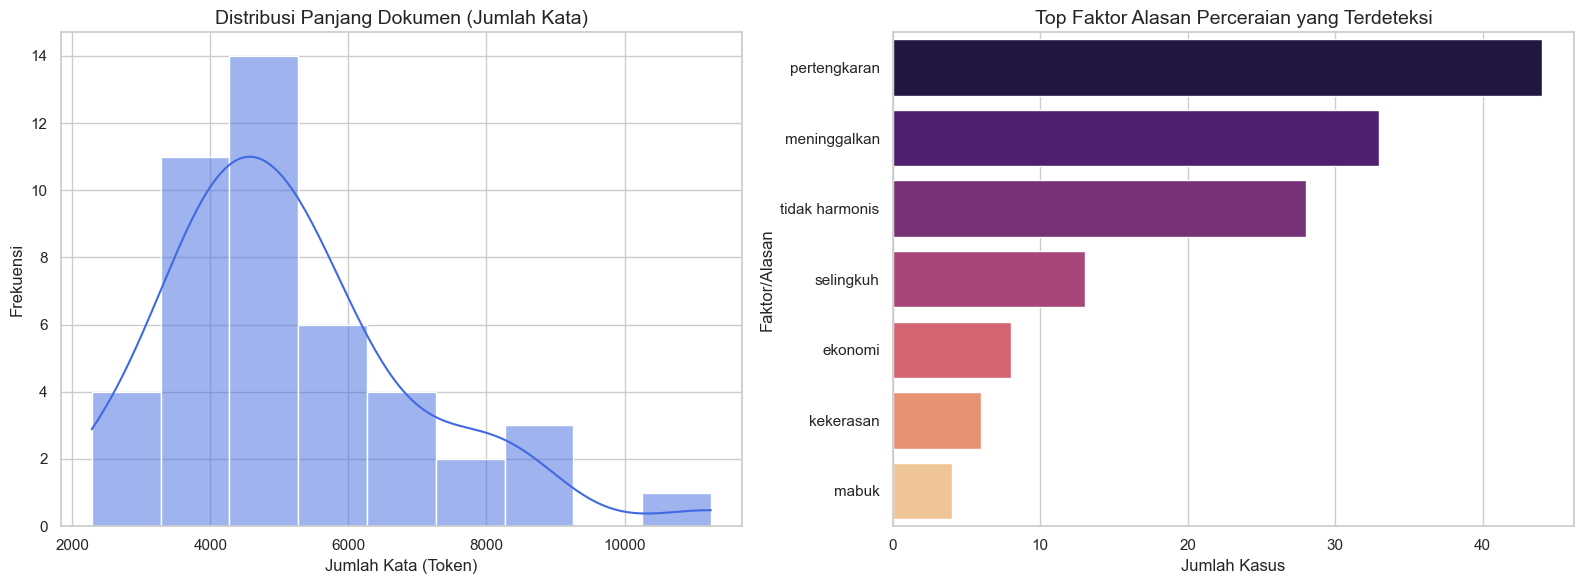

In [6]:
if not df_cases.empty:
    print("=== Ringkasan Validasi Ekstraksi Metadata ===")
    print(f"Total Dokumen: {len(df_cases)}")
    print(f"No Perkara Berhasil Ekstrak: {sum(df_cases['no_perkara'] != 'tidak ditemukan')} / {len(df_cases)}")
    print(f"Tanggal Berhasil Ekstrak: {sum(df_cases['tanggal'] != 'tidak ditemukan')} / {len(df_cases)}")
    print(f"Amar Putusan Ekstrak: {sum(df_cases['amar_putusan'] != 'tidak ditemukan')} / {len(df_cases)}")
    print(f"Rata-rata Token (Kata) per Dokumen: {df_cases['token_count'].mean():.0f} kata\n")
    
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Visualisasi 1: Distribusi Token Count
    sns.histplot(df_cases['token_count'], kde=True, ax=axes[0], color="royalblue")
    axes[0].set_title("Distribusi Panjang Dokumen (Jumlah Kata)", fontsize=14)
    axes[0].set_xlabel("Jumlah Kata (Token)")
    axes[0].set_ylabel("Frekuensi")

    # Visualisasi 2: Top Alasan Perceraian
    # Karena 1 putusan bisa memiliki lebih dari 1 alasan (koma separated)
    all_alasan = []
    for alasan_row in df_cases['alasan_perceraian']:
        all_alasan.extend([a.strip() for a in alasan_row.split(',')])
        
    alasan_counts = Counter(all_alasan).most_common(10)
    alasan_labels, alasan_vals = zip(*alasan_counts)
    
    sns.barplot(x=list(alasan_vals), y=list(alasan_labels), ax=axes[1], palette="magma")
    axes[1].set_title("Top Faktor Alasan Perceraian yang Terdeteksi", fontsize=14)
    axes[1].set_xlabel("Jumlah Kasus")
    axes[1].set_ylabel("Faktor/Alasan")

    plt.tight_layout()
    plt.show()
else:
    print("Dataset kosong.")

## 11. Kesimpulan Validasi Tahap 2
- File dataset `cases.csv` berhasil digenerasi dan menyertakan kolom yang wajib ada: `case_id`, `no_perkara`, `tanggal`, `ringkasan_fakta`, `pasal`, `pihak`, dan `text_full`.
- Dataset ini juga menyimpan fitur teknis NLP: `text_length`, `token_count`, `unique_word_count` yang sangat krusial untuk pemodelan TF-IDF.
- **Dataset 100% Siap** untuk diumpankan ke algoritma *Retrieval* (Tahap 3).